In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import seaborn as sns
from tqdm import tqdm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import mode

# Linear Regression

Заранее предупреждаем, что оценка, посчитанная в конце ноутбука не является итоговой, ноутбук будет запущен заново и проверка руками тоже будет. Эта оценка будет предварительной.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [3]:
grade_lst = []

### Dataset

ACME Insurance Inc. предлагает доступную медицинскую страховку тысячам клиентов по всей территории Соединенных Штатов. Перед вами стоит задача создать автоматизированную систему для оценки ежегодных расходов на медицинское обслуживание новых клиентов с использованием такой информации, как их возраст, пол, индекс массы тела, количество детей, привычки к курению и регион проживания.

[dataset](https://www.kaggle.com/datasets/harshsingh2209/medical-insurance-payout/data)

In [4]:
df = pd.read_csv('expenses.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## EDA

Проверьте есть ли пропущенные значения в столбцах

In [5]:
expenses_nans = df.isna().sum().sum()

print(expenses_nans)

0


Проверьте есть ли повторяющиеся строки

In [6]:
expenses_duplicates = df.duplicated().sum()

print(expenses_duplicates)

df.drop_duplicates(inplace=True)
# df.reset_index(inplace=True, drop=True)

1


### Кодировка категориальных признаков

Закодируйте категориальные признаки с помощью OneHotEncoder (используя drop='first')

In [7]:
from sklearn.preprocessing import OneHotEncoder

In [8]:
categorical = ['sex', 'smoker', 'region']

ohe = OneHotEncoder(drop='first', sparse_output=False)
df_cat = df[categorical].copy()

df_cat = ohe.fit_transform(df_cat)
df_cat = pd.DataFrame(df_cat,
                        columns=ohe.get_feature_names_out())

df_ = df.copy()

df_.drop(columns=categorical, inplace=True)

df_ = pd.concat([df_, df_cat], axis=1)
df_.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19.0,27.900,0.0,16884.92400,0.0,1.0,0.0,0.0,1.0
1,18.0,33.770,1.0,1725.55230,1.0,0.0,0.0,1.0,0.0
2,28.0,33.000,3.0,4449.46200,1.0,0.0,0.0,1.0,0.0
3,33.0,22.705,0.0,21984.47061,1.0,0.0,1.0,0.0,0.0
4,32.0,28.880,0.0,3866.85520,1.0,0.0,1.0,0.0,0.0


**Задание 1:** укажите в переменные mean_region, mean_sex, df_shape среднее значение по новой закодированной колонке region, среднее по колонке sex и размер нового датасета соответственно

In [9]:
# mean_region = encoded_df['region'].mean()
# mean_sex = encoded_df['sex'].mean()

mean_region = df_.filter(like='region').mean().mean()
mean_sex = df_.filter(like='sex').mean().mean()
df_shape = df_.shape

print(mean_region)
print(mean_sex)
print(df_shape)

grade_lst.append(mean_region)
grade_lst.append(mean_sex)
grade_lst.append(df_shape)

0.25255547245076043
0.5048616305160808
(1338, 9)


Постройте матрицу корреляций

In [10]:
import seaborn as sns

<Axes: >

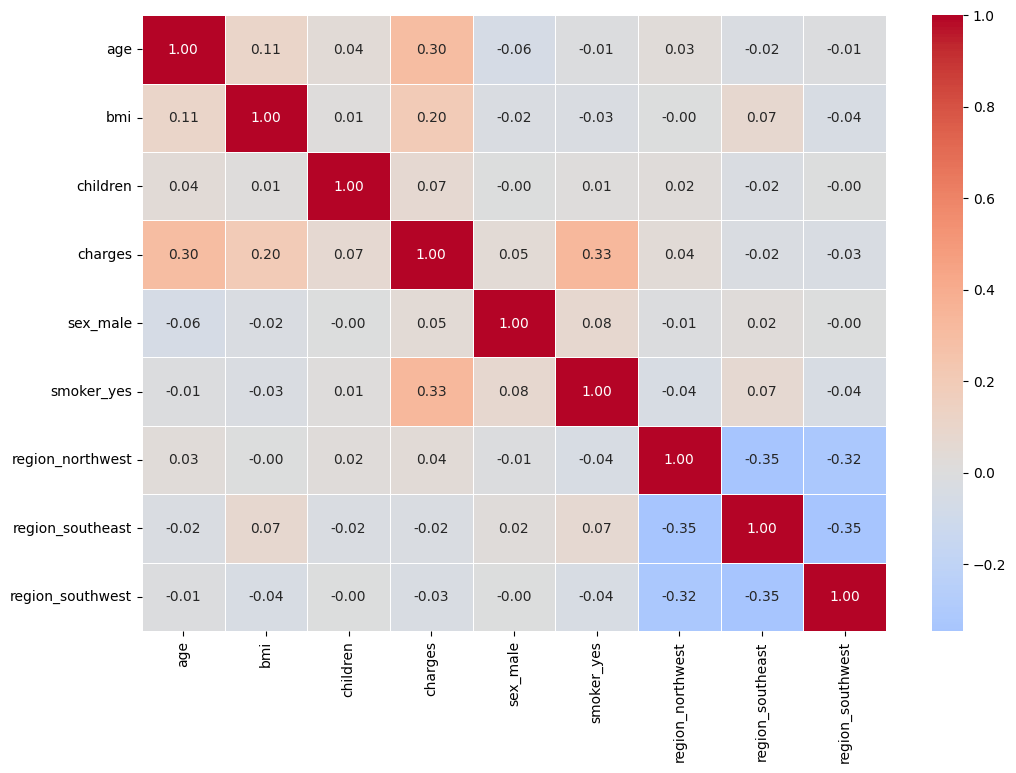

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

**Задание 2**: Укажите в ячейке ниже в переменную most_correlated признак, который больше всех коррелирует с целевой переменной (charges)

In [12]:
matr_corr = df_.corr()

target_col = 'charges'

corr_with_target = matr_corr[target_col].abs()

corr_with_target = corr_with_target.drop(target_col)

max_corr = corr_with_target.max()
most_correlated = corr_with_target.idxmax()

print(f"Максимальная корреляция с {target_col}: {most_correlated} = {max_corr:.3f}")
grade_lst.append(most_correlated)

Максимальная корреляция с charges: smoker_yes = 0.327


Линейная регрессия на входе должна иметь параметры одного масштаба, поэтому давайте отнормируем вещественные признаки с помощью StandardScaler

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
numerical = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_[numerical] = scaler.fit_transform(df_[numerical])
df_ = pd.DataFrame(df_, columns=df_.columns)

print(df_.shape)

(1338, 9)


Разделите данные на train и test часть (test_size=0.25, random_state=42)

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
matr_target = df_['charges']

matr_priznakov = df_.drop(columns=['charges'])

X_train, X_test, y_train, y_test = train_test_split(matr_priznakov,
                                                    matr_target,
                                                    test_size=0.25,
                                                    random_state=42)

valid_indices = X_train.dropna().index

X_train = X_train.loc[valid_indices]
y_train = y_train.loc[valid_indices]

X_train.shape, X_test.shape

((1001, 8), (335, 8))

### Модель

In [17]:
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [18]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

LinearRegression()

Изучите документацию модуля LinearRegression и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [19]:
y_pred = model1.predict(X_test)
quad_err_model1 = mean_squared_error(y_test, y_pred)
print(quad_err_model1)

y_train_pred = model1.predict(X_train)
quad_err_model1_train = mean_squared_error(y_train, y_train_pred)
print(quad_err_model1_train)


coefficients = model1.coef_
feature_names = X_train.columns

131596789.91040497
105800870.4060248


**Задание 3:** в переменную most_importnace_features укажите три признака, имеющих больший feature_importance

In [20]:
coefficients = model1.coef_
feature_names = X_train.columns

sorted_indices = np.argsort(np.abs(coefficients))[::-1]
sorted_features = feature_names[sorted_indices]

most_importance_features = sorted_features[:3].tolist()

print(most_importance_features)

grade_lst.append(most_importance_features.copy())

['smoker_yes', 'age', 'bmi']


#### Регуляризация

Один из важнейших пунктов при использовании линейных моделей, так как они являются достаточно слабыми, они всеми силами стараются переобучиться, поэтому мы используем регуляризацию, которая контроллирует норму весов, не давая коэфициентам становиться очень большими.

Cмысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:


$||y - X\hat{w}|| + \alpha \sum\limits_{i = 1}^n |w_i|$


Такая модель называется **Lasso-регрессией**.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:


$||y - X\hat{w}|| + \alpha \sum\limits_{i = 1}^n ||w_i||^2$

Такая модель называется **Ridge-регрессией**.

Обучите Lasso-регрессию и Ridge-регрессию, уставновив гиперпараметр регуляризации равным 10. Для этого используйте модули Lasso и Ridge из sklearn.

In [21]:
model2 = Lasso(alpha=10)
model2.fit(X_train, y_train)

model3 = Ridge(alpha=10)
model3.fit(X_train, y_train)

Ridge(alpha=10)

**Задание 4:** Укажите в переменную best_model какая модель дала лучшее качество на тесте (Lasso или Ridge)

In [22]:
y_pred_2 = model2.predict(X_test)
quad_err_model2 = mean_squared_error(y_test, y_pred_2)
print(quad_err_model2)

y_pred_3 = model3.predict(X_test)
quad_err_model3 = mean_squared_error(y_test, y_pred_3)
print(quad_err_model3)

best_model = ""

if quad_err_model2 < quad_err_model3:
  best_model = "lasso"
else:
  best_model = "ridge"

print(best_model)

grade_lst.append(best_model)

131578759.86937726
131674528.28357127
lasso


Постройте график нормы вектора коэфициентов для коэфициентов регуляризации (0.1, 1, 10, 100, 1000, 10000).

Как мы знаем Lasso зануляет коэфициенты при достаточно больших коэфициентах регуляризации. Для каждого коэфициента зафиксируйте количество признаков, у которых ненулевой feature_importance

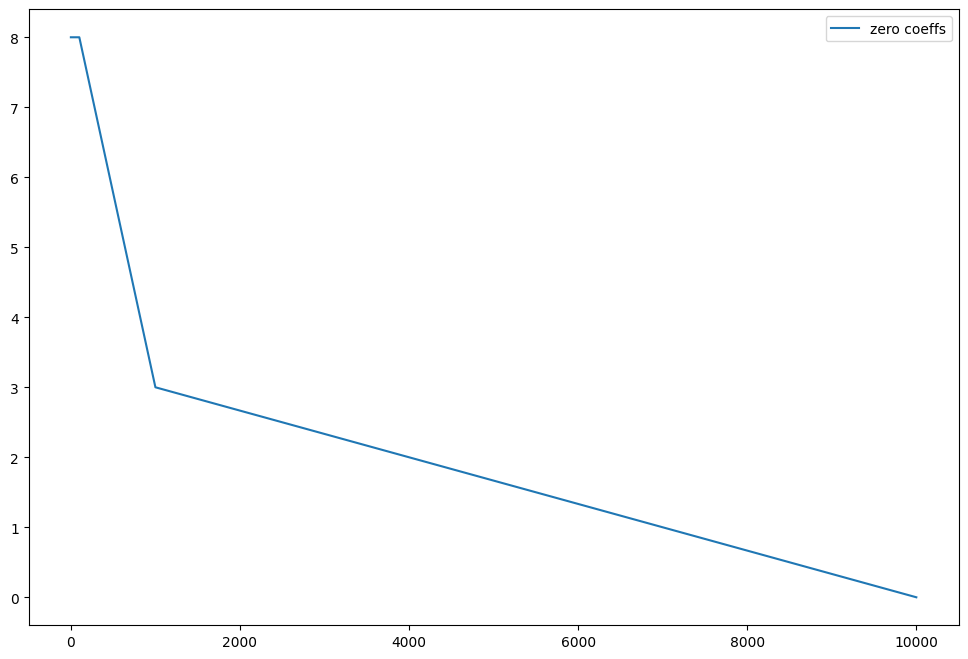

In [23]:
alpha_coeffs = [0.1, 1, 10, 100, 1000, 10000]

n_coefs = []
norms = []

for alpha in alpha_coeffs:
  model_i = Lasso(alpha=alpha, max_iter=10000)
  model_i.fit(X_train, y_train)

  coefs = model_i.coef_
  n_nonzero = np.sum(coefs != 0)
  n_coefs.append(n_nonzero)

  norm = np.sum(np.abs(coefs))
  norms.append(norm)

plt.figure(figsize=(12, 8))
plt.plot(alpha_coeffs, n_coefs, label='zero coeffs')
plt.legend()
plt.show()

**Задание 5:** Укажите для какого коэфициенте регуляризации у Lasso остается всего 3 коэфициента с ненулевым feature_importance

In [24]:
three_non_zero_features_alpha = -100

for i in range(len(alpha_coeffs)):
  if  n_coefs[i] == 3:
    three_non_zero_features_alpha = alpha_coeffs[i]

print(three_non_zero_features_alpha)

grade_lst.append(three_non_zero_features_alpha)

1000


Давайте вспомним про кросс-валидацию, это метод оценивания качества модели на тренировочной выборке, работает по следующему алгоритму:

1. Делим выборку на некоторое количество фолдов (обычно 5)

2. Обучаем модель на всех кроме одного фолда, и на оставшемся фолде оцениваем качество

3. Повторяем пункт 2 для всех фолдов

4. В конце считаем среднее качество по всем фолдам

Итого обучаем 5 раз модель (в этом минус кросс-валидации, если данных много или модель тяжелая, то она может затянуться)


Используя LassoCV с количеством фолдов 5 посчитайте для каждого alpha из предыдущего задания MSE на кросс-валидации

In [25]:
from sklearn.linear_model import LassoCV

alphas = [0.1, 1, 10, 100, 1000, 10000]

model_lassoCV = LassoCV(alphas=alphas, cv=5, random_state=42)

model_lassoCV.fit(X_train, y_train)
mse_scores = np.mean(model_lassoCV.mse_path_, axis=1)

for alpha, mse in zip(model_lassoCV.alphas_, mse_scores):
    print(f"Alpha: {alpha}, MSE: {mse}")

Alpha: 10000.0, MSE: 141179060.0896866
Alpha: 1000.0, MSE: 116251084.75025456
Alpha: 100.0, MSE: 108120658.57781386
Alpha: 10.0, MSE: 108276594.97525445
Alpha: 1.0, MSE: 108361252.38299036
Alpha: 0.1, MSE: 108371041.30205044


**Задание 6:** Запишите в переменную best_lasso_alpha коэфициент alpha, при котором достигается наименьший MSE на кросс-валидации

In [26]:
best_lasso_alpha = model_lassoCV.alpha_

print(best_lasso_alpha)

grade_lst.append(best_lasso_alpha)

100.0


Обучите Lasso с лучшим alpha и посчитайте MSE на тесте

In [27]:
model4 = Lasso(alpha=100)
model4.fit(X_train, y_train)

y_pred_model4 = model4.predict(X_test)
quad_err_model4 = mean_squared_error(y_test, y_pred_model4)
print(quad_err_model4)

131682279.67526115


### Полиномиальные признаки

Линейная регрессия является слабой как раз по причине того, что она собирает лишь линейную комбинацию имеющихся признаков. Поэтому для улучшения можно добавить полиномиальных признаков руками (степени признаков, или произведения признаков).

In [28]:
from sklearn.preprocessing import PolynomialFeatures
import time

Посчитайте для degree = [2, 3, 4, 5, 6, 7, 8, 9, 10] количество признаков и время за которое обучается модель

In [43]:
degrees = [2, 3, 4, 5, 6, 7, 8, 9, 10]

feature = []
times = []
mean_squared_errors = []

for degree in degrees:
  poly = PolynomialFeatures(degree=degree)
  X_train_poly = poly.fit_transform(X_train)
  X_test_poly = poly.transform(X_test)

  features = X_train_poly.shape[1]
  feature.append(features)

  start = time.time()
  model_i_1 = LinearRegression()
  model_i_1.fit(X_train_poly, y_train)
  fit_time = time.time() - start
  times.append(fit_time)

  y_pred_i_1 = model_i_1.predict(X_test_poly)
  mean_squared_error_1 = mean_squared_error(y_test, y_pred_i_1)
  mean_squared_errors.append(mean_squared_error_1)

print(times)
print(features)
print(mean_squared_errors)

[0.003920316696166992, 0.12127852439880371, 0.3828768730163574, 4.089037895202637, 7.096110820770264, 5.119783639907837, 6.402564764022827, 6.60399603843689, 25.386948108673096]
43758
[136615239.92023557, 148156586.97307414, 257181899.88845974, 1989075986.8125489, 155968120261.2374, 13031338328208.758, 1.1447243142357382e+20, 7.588428854583049e+21, 8.820031734384791e+18]


**Задание 7:** Укажите в переменную degree_8_n_features сколько признаков в датасете при 8 степени полинома

In [44]:
degree_8_n_features = 0

for i in range(len(degrees)):
  if degrees[i] == 8:
    degree_8_n_features = feature[i]

print(degree_8_n_features)

grade_lst.append(degree_8_n_features)

12870


**Задание 8:** Укажите в переменную best_degree степень, при которой MSE на тесте лучшее

In [46]:
best_degree = -10

for i in range(len(degrees)):
  if mean_squared_errors[i] == min(mean_squared_errors):
    best_degree = degrees[i]

print(best_degree)

grade_lst.append(best_degree)

2


Постройте следующие графики в зависимости от степени полинома:

1. Количество признаков

2. Время обучения

3. Качество на тесте

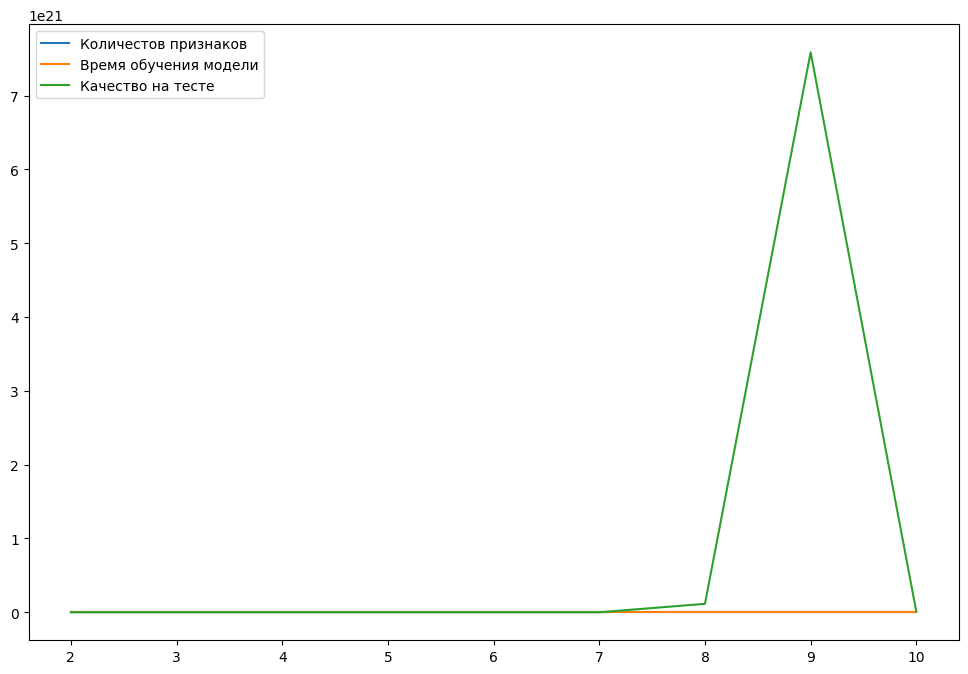

In [47]:
plt.figure(figsize=(12, 8))
plt.plot(degrees, feature, label='Количестов признаков')
plt.plot(degrees, times, label='Время обучения модели')
plt.plot(degrees, mean_squared_errors, label='Качество на тесте')
plt.legend()
plt.show()

## Оценка

In [48]:
# def grade(grade_lst, epsilon=10e-4):
#     if len(grade_lst) < 10:
#         grade_lst += [-float('inf')] * (10 - len(grade_lst))

#     res = 0
#     if abs(grade_lst[0] - 0.20478325859491778) < epsilon:
#         res += 1
#     if abs(grade_lst[1] - 0.5052316890881914) < epsilon:
#         res += 1
#     if grade_lst[2] == 9:
#         res += 1
#     if grade_lst[3] == 'smoker_yes':
#         res += 1

#     res += int('smoker_yes' in grade_lst[4]) / 3
#     res += int('age' in grade_lst[4]) / 3
#     res += int('bmi' in grade_lst[4]) / 3

#     res += int(grade_lst[5].lower() == 'lasso')

#     res += int(grade_lst[6] == 1000)

#     res += int(grade_lst[7] == 100)

#     res += int(grade_lst[8] == 12870)

#     res += int(grade_lst[9] < 4)

#     return res


# grade(grade_lst)

TypeError: '<' not supported between instances of 'ellipsis' and 'int'